In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [6]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
df = pd.read_csv(url, header=None)
print("Dataset shape:", df.shape)
df.head()



Dataset shape: (581012, 55)


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [27]:
X = df.iloc[:, :54].values
y = df.iloc[:, 54].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (581012, 54)
y shape: (581012,)
Classes: [1 2 3 4 5 6 7]


In [31]:
X = df.iloc[:, :54].values
y = df.iloc[:, 54].values

y = y - 1

print("Classes:", np.unique(y))

Classes: [0 1 2 3 4 5 6]


Class 1 : 211840
Class 2 : 283301
Class 3 : 35754
Class 4 : 2747
Class 5 : 9493
Class 6 : 17367
Class 7 : 20510


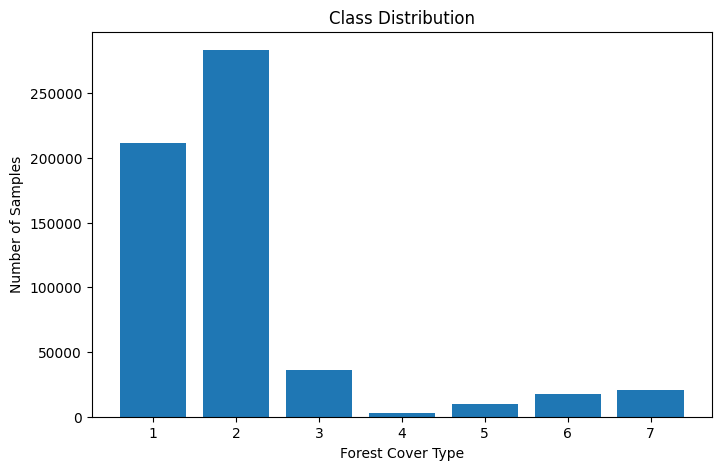

Imbalance ratio: 103.13105205678923


In [32]:
class_counts = np.bincount(y)

for i, count in enumerate(class_counts):
    print("Class", i + 1, ":", count)

plt.figure(figsize=(8, 5))
plt.bar(range(1, 8), class_counts)
plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()

print("Imbalance ratio:", imbalance_ratio)

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (464809, 54) (464809,)
Validation: (58101, 54) (58101,)
Testing: (58102, 54) (58102,)


In [35]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training mean:", np.mean(X_train))
print("Training standard deviation:", np.std(X_train))

Training mean: 5.881850099515721e-16
Training standard deviation: 1.0000000000004086


In [36]:
num_classes = 7

y_train_onehot = np.eye(num_classes)[y_train]
y_val_onehot = np.eye(num_classes)[y_val]
y_test_onehot = np.eye(num_classes)[y_test]

print("One-hot shape:", y_train_onehot.shape)

One-hot shape: (464809, 7)


In [13]:
N = len(y_train)
K = 7

class_weights = {}

for c in range(K):
    class_weights[c] = N / (K * np.sum(y_train == c))

print("Class weights:")

for c in range(K):
    print("Class", c + 1, ":", class_weights[c])

Class weights:
Class 1 : 0.39181272253992233
Class 2 : 0.29298131712974634
Class 3 : 2.3214797648598298
Class 4 : 30.209866112049916
Class 5 : 8.743914368486399
Class 6 : 4.779133850171708
Class 7 : 4.046884794873581


In [14]:
def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [15]:
np.random.seed(42)

W1 = np.random.randn(54, 64) * np.sqrt(2 / 54)
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
b2 = np.zeros((1, 32))

W3 = np.random.randn(32, 16) * np.sqrt(2 / 32)
b3 = np.zeros((1, 16))

W4 = np.random.randn(16, 7) * np.sqrt(2 / 16)
b4 = np.zeros((1, 7))

print("W1:", W1.shape)
print("W2:", W2.shape)
print("W3:", W3.shape)
print("W4:", W4.shape)

W1: (54, 64)
W2: (64, 32)
W3: (32, 16)
W4: (16, 7)


In [16]:
def forward(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)

    Z4 = A3 @ W4 + b4
    Y_hat = softmax(Z4)

    cache = (X, Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat)

    return Y_hat, cache

In [17]:
def weighted_cross_entropy(Y, Y_hat, labels):
    eps = 1e-12
    Y_hat = np.clip(Y_hat, eps, 1 - eps)

    weights = np.array([class_weights[c] for c in labels])

    loss = -np.sum(
        weights[:, None] * Y * np.log(Y_hat)
    ) / len(Y)

    return loss

In [18]:
def backward(cache, Y, labels):
    X, Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat = cache

    batch_size = X.shape[0]

    weights = np.array([class_weights[c] for c in labels])

    dZ4 = (Y_hat - Y) * weights[:, None] / batch_size

    dW4 = A3.T @ dZ4
    db4 = np.sum(dZ4, axis=0, keepdims=True)

    dA3 = dZ4 @ W4.T
    dZ3 = dA3 * relu_derivative(Z3)

    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3, dW4, db4

In [19]:
def predict(X):
    Y_hat, _ = forward(X)
    return np.argmax(Y_hat, axis=1)


def calculate_loss(X, Y, labels):
    Y_hat, _ = forward(X)
    return weighted_cross_entropy(Y, Y_hat, labels)


def calculate_accuracy(X, y):
    predictions = predict(X)
    return np.mean(predictions == y)

In [20]:
learning_rate = 0.01
batch_size = 128
epochs = 100
patience = 15

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = np.inf
best_weights = None
patience_counter = 0

for epoch in range(epochs):

    indices = np.random.permutation(len(X_train))

    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    y_train_onehot_shuffled = y_train_onehot[indices]

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]
        Y_batch = y_train_onehot_shuffled[start:end]

        Y_hat, cache = forward(X_batch)

        gradients = backward(cache, Y_batch, y_batch)

        dW1, db1, dW2, db2, dW3, db3, dW4, db4 = gradients

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

        W4 -= learning_rate * dW4
        b4 -= learning_rate * db4

    train_loss = calculate_loss(
        X_train,
        y_train_onehot,
        y_train
    )

    val_loss = calculate_loss(
        X_val,
        y_val_onehot,
        y_val
    )

    train_accuracy = calculate_accuracy(X_train, y_train)
    val_accuracy = calculate_accuracy(X_val, y_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f} "
        f"- Train Acc: {train_accuracy:.4f} "
        f"- Val Acc: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_weights = (
            W1.copy(), b1.copy(),
            W2.copy(), b2.copy(),
            W3.copy(), b3.copy(),
            W4.copy(), b4.copy()
        )

        patience_counter = 0

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

Epoch 1/100 - Train Loss: 0.6914 - Val Loss: 0.6997 - Train Acc: 0.5829 - Val Acc: 0.5828
Epoch 2/100 - Train Loss: 0.6252 - Val Loss: 0.6291 - Train Acc: 0.6162 - Val Acc: 0.6173
Epoch 3/100 - Train Loss: 0.5844 - Val Loss: 0.5923 - Train Acc: 0.6375 - Val Acc: 0.6383
Epoch 4/100 - Train Loss: 0.5763 - Val Loss: 0.5884 - Train Acc: 0.6821 - Val Acc: 0.6836
Epoch 5/100 - Train Loss: 0.5458 - Val Loss: 0.5588 - Train Acc: 0.6655 - Val Acc: 0.6645
Epoch 6/100 - Train Loss: 0.5251 - Val Loss: 0.5324 - Train Acc: 0.6753 - Val Acc: 0.6763
Epoch 7/100 - Train Loss: 0.5315 - Val Loss: 0.5432 - Train Acc: 0.6769 - Val Acc: 0.6781
Epoch 8/100 - Train Loss: 0.5097 - Val Loss: 0.5204 - Train Acc: 0.6666 - Val Acc: 0.6669
Epoch 9/100 - Train Loss: 0.5003 - Val Loss: 0.5123 - Train Acc: 0.6927 - Val Acc: 0.6948
Epoch 10/100 - Train Loss: 0.4884 - Val Loss: 0.5021 - Train Acc: 0.6926 - Val Acc: 0.6941
Epoch 11/100 - Train Loss: 0.4895 - Val Loss: 0.4997 - Train Acc: 0.7017 - Val Acc: 0.7026
Epoch 12

In [21]:
y_pred = predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 0.7274792606106503
Test Accuracy (%): 72.74792606106503


In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Spruce/Fir",
            "Lodgepole Pine",
            "Ponderosa Pine",
            "Cottonwood/Willow",
            "Aspen",
            "Douglas-fir",
            "Krummholz"
        ]
    )
)

                   precision    recall  f1-score   support

       Spruce/Fir       0.90      0.51      0.65     21184
   Lodgepole Pine       0.79      0.84      0.82     28331
   Ponderosa Pine       0.83      0.76      0.79      3576
Cottonwood/Willow       0.56      0.96      0.71       274
            Aspen       0.35      0.97      0.51       949
      Douglas-fir       0.53      0.92      0.67      1737
        Krummholz       0.32      1.00      0.48      2051

         accuracy                           0.73     58102
        macro avg       0.61      0.85      0.66     58102
     weighted avg       0.80      0.73      0.73     58102



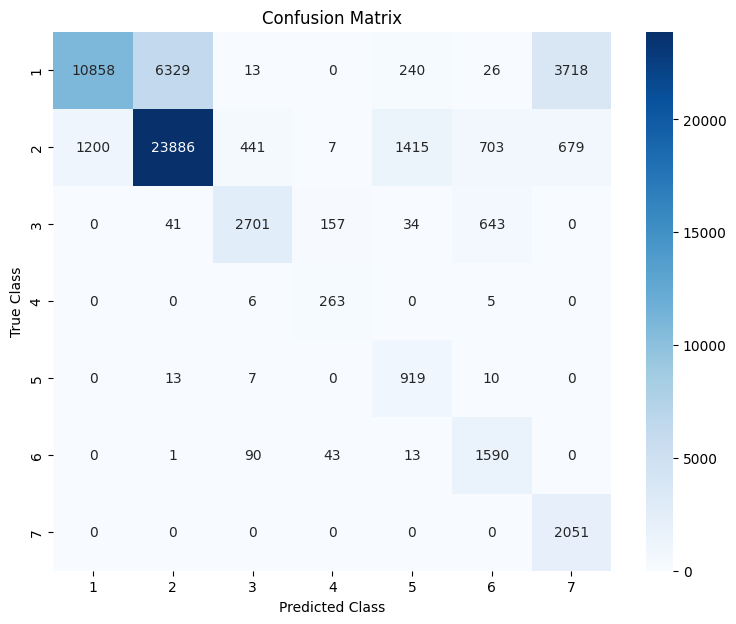

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(1, 8),
    yticklabels=range(1, 8)
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

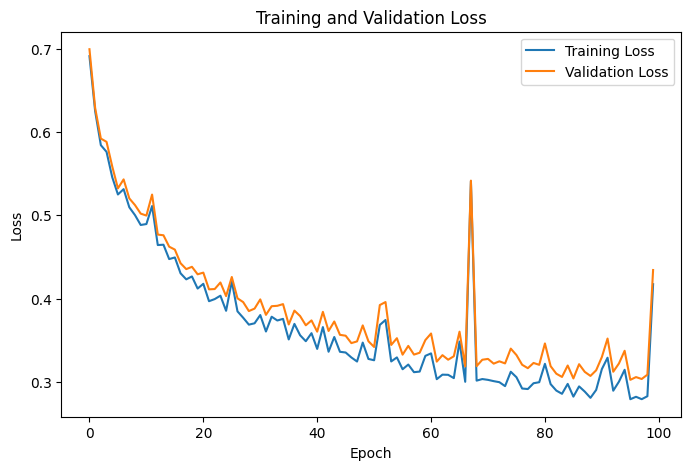

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

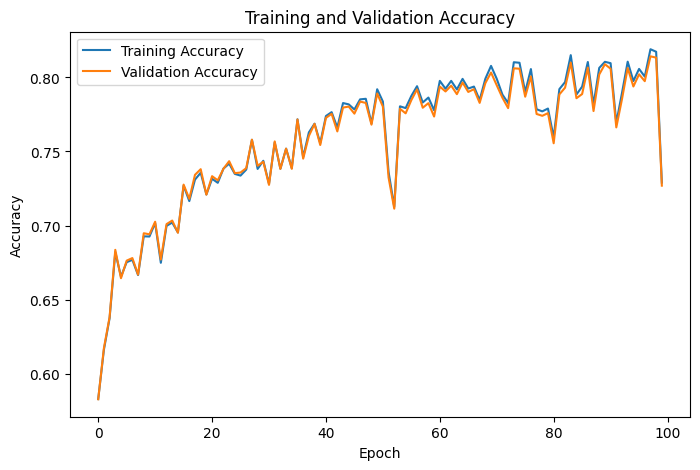

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

In [ ]:
f1_scores = f1_score(
    y_test,
    y_pred,
    average=None
)

class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

plt.figure(figsize=(10, 5))

plt.bar(class_names, f1_scores)

plt.xlabel("Forest Cover Type")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

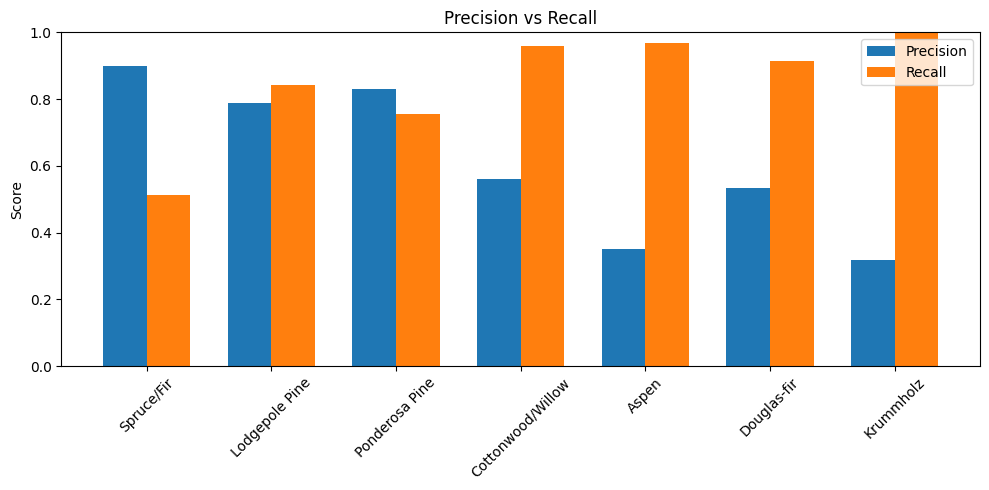

In [38]:
class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

precision = precision_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    recall,
    width,
    label="Recall"
)

plt.xticks(x, class_names, rotation=45)
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

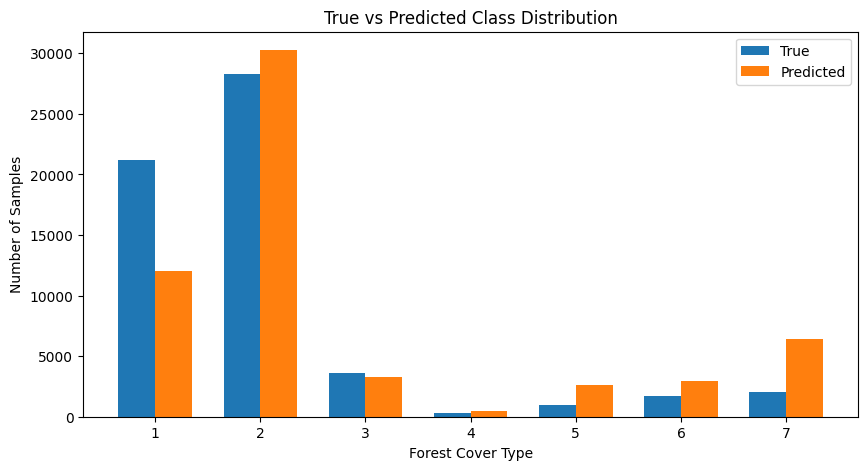

In [39]:
true_counts = np.bincount(y_test, minlength=7)
pred_counts = np.bincount(y_pred, minlength=7)

x = np.arange(7)
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True"
)

plt.bar(
    x + width / 2,
    pred_counts,
    width,
    label="Predicted"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")

plt.xticks(x, range(1, 8))
plt.legend()

plt.show()